In [1]:
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/model_ready.csv')

X = df.drop(columns=['ID', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

with open('../data/processed/baseline_results.json') as f:
    baseline_results = json.load(f)
baseline_results

{'logistic_regression': {'roc_auc': 0.5597956195770635},
 'decision_tree': {'roc_auc': 0.5615449082374768}}

### Random Forest with Class Weighing

In [2]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96      7169
           1       0.10      0.39      0.16       123

    accuracy                           0.93      7292
   macro avg       0.55      0.67      0.56      7292
weighted avg       0.97      0.93      0.95      7292

ROC-AUC: 0.6900045022210579


### XGBoost with scale_pos_weight
XGBoost handles imbalance via scale_pos_weight

In [3]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

scale_pos_weight: 58.15821501014199
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      7169
           1       0.16      0.47      0.24       123

    accuracy                           0.95      7292
   macro avg       0.57      0.71      0.61      7292
weighted avg       0.98      0.95      0.96      7292

ROC-AUC: 0.7248320739589038


### Trying SMOTE as an alternative imbalance strategy
SMOTE synthesizes new minority-class examples rather than just reweighting — worth comparing against class-weighting directly

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

xgb_smote = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss'
)
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_proba_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_smote))

Before SMOTE: {0: 28672, 1: 493}
After SMOTE: {0: 28672, 1: 28672}
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.19      0.20      0.20       123

    accuracy                           0.97      7292
   macro avg       0.59      0.59      0.59      7292
weighted avg       0.97      0.97      0.97      7292

ROC-AUC: 0.6904654979036887


### Threshold Tuning

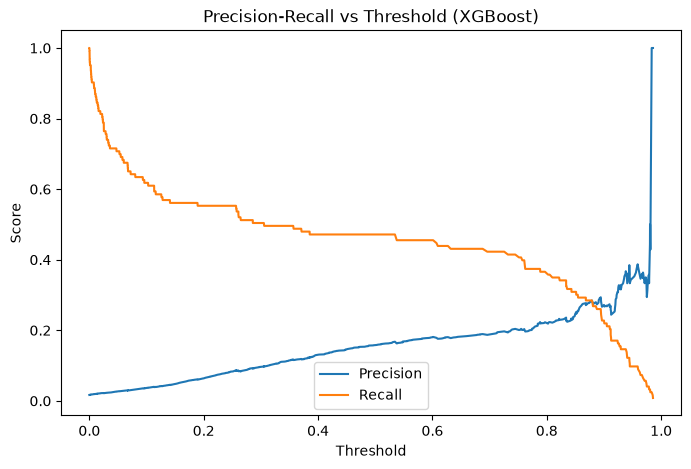

              precision    recall  f1-score   support

           0       0.99      0.92      0.95      7169
           1       0.10      0.50      0.16       123

    accuracy                           0.91      7292
   macro avg       0.54      0.71      0.56      7292
weighted avg       0.98      0.91      0.94      7292



In [9]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold (XGBoost)')
plt.legend()
plt.show()

# Try a custom threshold and see the tradeoff
custom_threshold = 0.3
y_pred_custom = (y_proba_xgb >= custom_threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

### Compare all models side by side

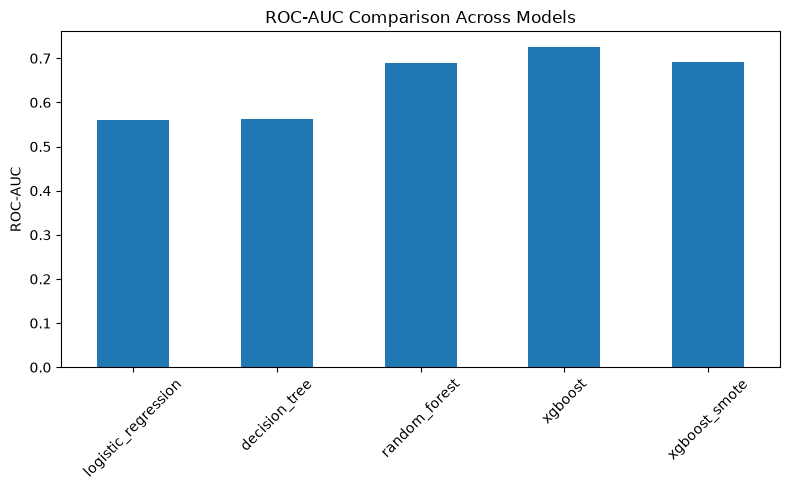

,roc_auc
logistic_regression,0.559796
decision_tree,0.561545
random_forest,0.690005
xgboost,0.724832
xgboost_smote,0.690465


In [10]:
results = {
    **baseline_results,
    'random_forest': {'roc_auc': float(roc_auc_score(y_test, y_proba_rf))},
    'xgboost': {'roc_auc': float(roc_auc_score(y_test, y_proba_xgb))},
    'xgboost_smote': {'roc_auc': float(roc_auc_score(y_test, y_proba_xgb_smote))},
}

comparison_df = pd.DataFrame(results).T
comparison_df.plot(kind='bar', legend=False, figsize=(8, 5))
plt.title('ROC-AUC Comparison Across Models')
plt.ylabel('ROC-AUC')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

comparison_df

In [12]:
import joblib

best_model = xgb
joblib.dump(best_model, '../data/processed/best_model.pkl')

with open('../data/processed/final_results.json', 'w') as f:
    json.dump(results, f, indent=2)